<a href="https://colab.research.google.com/github/santosoj160/Strategic-Growth-Insights-Funnel-Cohort-Analysis/blob/main/Cohort_%26_Funnel_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Cohort Analysis

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load Dataset dari Google Drive (Ganti path di bawah ini dengan hasil 'Copy path' kamu)
file_path = '/content/drive/MyDrive/PROJECT DATA ANALITICS/Cohort & Funnel Analyst/Assignment Cohort Data - Fintech Data.xlsx'
df = pd.read_excel(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# 3. Format Kolom Tanggal
df['date'] = pd.to_datetime(df['date'])

In [28]:
# 4. Hitung Transaction Month & Cohort Month
df['Transaction_Month'] = df['date'].dt.to_period('M')
df['Cohort_Month'] = df.groupby('username')['date'].transform('min').dt.to_period('M')

In [29]:
# 5. Hitung Selisih Bulan (Cohort Index)
df['Cohort_Index'] = (df['Transaction_Month'] - df['Cohort_Month']).apply(lambda x: x.n)

In [30]:
# 6. Buat Matriks Retention Rate (%)
cohort_data = df.groupby(['Cohort_Month', 'Cohort_Index'])['username'].nunique().reset_index()
cohort_matrix = cohort_data.pivot(index='Cohort_Month', columns='Cohort_Index', values='username')

cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0) * 100

## 1.1 Matriks Retention

In [31]:
# 7. Tampilkan Matriks
styled_matrix = (
    retention_matrix.style
    .background_gradient(cmap='YlGnBu', axis=None, low=0, high=1)
    .format("{:.1f}%", na_rep="") # Menampilkan % dan menyembunyikan NaN
    .set_caption("Matriks User Retention Rate (%) per Cohort")
)

display(styled_matrix)

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2024-01,100.0%,79.1%,73.9%,73.9%,72.2%,69.6%,66.1%,62.6%,61.7%,56.5%,50.4%,59.1%
2024-02,100.0%,26.7%,33.3%,33.3%,20.0%,26.7%,20.0%,6.7%,13.3%,13.3%,26.7%,
2024-03,100.0%,71.4%,42.9%,42.9%,42.9%,42.9%,57.1%,71.4%,42.9%,85.7%,,
2024-04,100.0%,37.5%,75.0%,62.5%,62.5%,75.0%,62.5%,75.0%,62.5%,,,
2024-05,100.0%,66.7%,66.7%,77.8%,66.7%,77.8%,44.4%,55.6%,,,,
2024-06,100.0%,83.3%,83.3%,66.7%,50.0%,50.0%,33.3%,,,,,
2024-07,100.0%,90.0%,90.0%,90.0%,90.0%,90.0%,,,,,,
2024-08,100.0%,58.3%,75.0%,66.7%,75.0%,,,,,,,
2024-09,100.0%,76.9%,61.5%,76.9%,,,,,,,,


## 1.2 Visualisasi Heatmap & Retention Curve

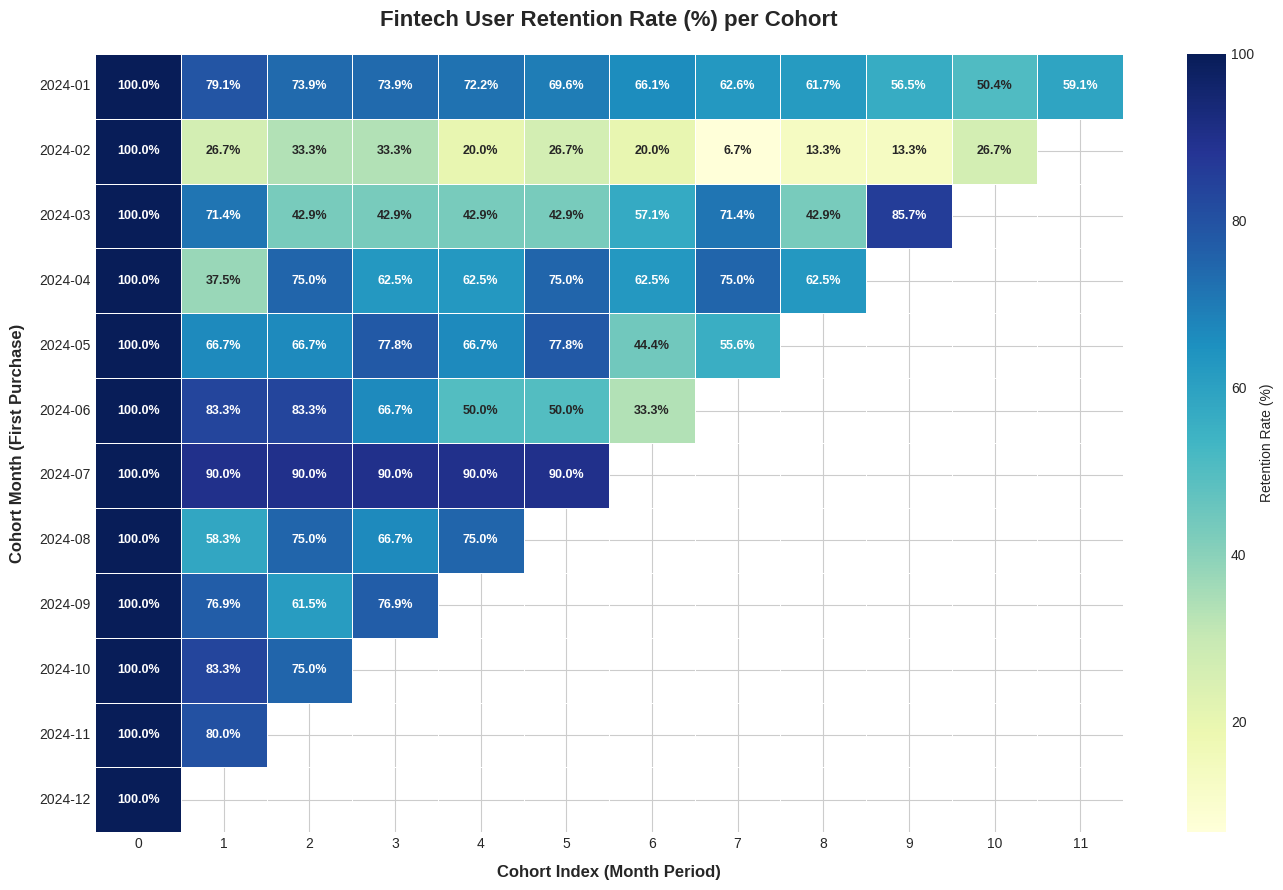

In [32]:
# 8. Visualisasi Heatmap
plt.figure(figsize=(14, 9), dpi=100)

# Heatmap dengan grid garis pemisah dan angka bertanda %
ax = sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,       # Garis pemisah antar sel
    linecolor='white',    # Warna garis pemisah
    cbar_kws={'label': 'Retention Rate (%)'},
    annot_kws={"size": 9, "weight": "bold"} # Ukuran & ketebalan angka
)

# Menambahkan tanda '%' pada teks annotation angka
for t in ax.texts:
    if t.get_text() != 'nan':
        t.set_text(t.get_text() + '%')

# Formatting Judul dan Label Sumbu
plt.title('Fintech User Retention Rate (%) per Cohort', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cohort Index (Month Period)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Cohort Month (First Purchase)', fontsize=12, fontweight='bold', labelpad=10)

# Merapikan rotasi label sumbu X dan Y
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## 1.3 Strategic Insights (Cohort)

### Strategic Insights - Cohort Analysis (Fintech Data)

1. **Performa Retensi Secara Umum Sangat Sehat:**
   * Sebagian besar cohort pengguna mampu mempertahankan *Retention Rate* di atas **50% – 70%** bahkan setelah 5 hingga 10 bulan berjalan. Ini menandakan produk Fintech memiliki *product-market fit* yang kuat dan basis pengguna yang loyal.

2. **Performa Terbaik (*Best Performing Cohort*):**
   * **Cohort Juli 2024 (`2024-07`)** mencatatkan retensi paling impresif dan stabil. Hingga bulan ke-5 (`Cohort_Index 5`), sebesar **90.0%** pengguna masih aktif bertransaksi.
   * *Insight:* Strategi *onboarding* atau promo pada bulan Juli 2024 sangat berhasil menarik pengguna berkualitas tinggi (*high-value users*).

3. **Anomali Retensi Terburuk (*Worst Performing Cohort*):**
   * **Cohort Februari 2024 (`2024-02`)** mengalami *drop-off* drastis di bulan pertama (`Cohort_Index 1`), di mana retensi merosot tajam hingga tersisa **26.7%** (dibandingkan cohort Januari yang bertahan di **79.1%**).
   * *Insight:* Perlu adanya investigasi mendalam terhadap kampanye pemasaran atau kendala teknis pada aplikasi di bulan Februari 2024 untuk mengetahui penyebab tingginya angka *churn* tersebut.

# 2. Funnel Analysis

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset Funnel dari Google Drive
# Ganti path berikut sesuai dengan lokasi file Education Startup kamu di Drive
file_path_funnel = '/content/drive/MyDrive/PROJECT DATA ANALITICS/Cohort & Funnel Analyst/Funnel Data - Assignment Education Startup Data.xlsx'
df_funnel = pd.read_excel(file_path_funnel)

# 2. Cek Struktur Kolom Dataset
print("=== STRUKTUR KOLOM DATASET FUNNEL ===")
print(df_funnel.head())

=== STRUKTUR KOLOM DATASET FUNNEL ===
      Stage   Count                    Customer Group
0     Leads   57022  Kindergarten & Elementary School
1     Leads  327400                     Middle School
2     Leads  245916                       High School
3  Bookings   37044  Kindergarten & Elementary School
4  Bookings  234426                     Middle School


In [34]:
# 3. Hitung Total Count per Stage (Overall Business Funnel)
# Mengurutkan tahapan sesuai hirarki bisnis
stage_order = ['Leads', 'Bookings', 'User'] # Sesuaikan jika ada nama stage lain seperti Visit/Purchase
funnel_summary = df_funnel.groupby('Stage')['Count'].sum().reindex(stage_order).dropna().reset_index()

## 2.1 Ringkasan Conversion & Drop-off

In [35]:
# 4. Hitung Conversion Rate & Drop-off Rate
# Overall Conversion Rate (dibandingkan dengan Stage Pertama)
initial_count = funnel_summary['Count'].iloc[0]
funnel_summary['Overall_CR (%)'] = (funnel_summary['Count'] / initial_count) * 100
# Step-by-Step Conversion Rate (dibandingkan dengan Stage Sebelumnya)
funnel_summary['Step_CR (%)'] = (funnel_summary['Count'] / funnel_summary['Count'].shift(1)) * 100
funnel_summary['Step_CR (%)'] = funnel_summary['Step_CR (%)'].fillna(100.0)

# Drop-off Rate (%)
funnel_summary['Drop_Off_Rate (%)'] = 100.0 - funnel_summary['Step_CR (%)']

print("=== RINGKASAN FUNNEL BUSINESS OVERALL ===")
print(funnel_summary.round(2))

=== RINGKASAN FUNNEL BUSINESS OVERALL ===
      Stage     Count  Overall_CR (%)  Step_CR (%)  Drop_Off_Rate (%)
0     Leads  630338.0          100.00       100.00               0.00
1  Bookings  417400.0           66.22        66.22              33.78


## 2.2 Breakdown per Customer Group

In [36]:
# 5. BREAKDOWN FUNNEL PER CUSTOMER GROUP
group_funnel = df_funnel.pivot(index='Customer Group', columns='Stage', values='Count').reindex(columns=stage_order)
group_funnel['Leads_to_Bookings_CR (%)'] = (group_funnel['Bookings'] / group_funnel['Leads']) * 100

print("\n=== FUNNEL BREAKDOWN PER CUSTOMER GROUP ===")
print(group_funnel.round(2))


=== FUNNEL BREAKDOWN PER CUSTOMER GROUP ===
Stage                              Leads  Bookings  User  \
Customer Group                                             
High School                       245916    145930   NaN   
Kindergarten & Elementary School   57022     37044   NaN   
Middle School                     327400    234426   NaN   

Stage                             Leads_to_Bookings_CR (%)  
Customer Group                                              
High School                                          59.34  
Kindergarten & Elementary School                     64.96  
Middle School                                        71.60  


In [37]:
# Re-create group_funnel to ensure it's defined in this cell's scope
group_funnel = df_funnel.pivot(index='Customer Group', columns='Stage', values='Count').reindex(columns=stage_order)
group_funnel['Leads_to_Bookings_CR (%)'] = (group_funnel['Bookings'] / group_funnel['Leads']) * 100

print("\n=== FUNNEL BREAKDOWN PER CUSTOMER GROUP (Original Format) ===")
print(group_funnel.round(2))

print("\n=== FUNNEL BREAKDOWN PER CUSTOMER GROUP ===")
pivot_table = pd.pivot_table(group_funnel.reset_index(),
                             index='Customer Group',
                             values=['Leads', 'Bookings', 'Leads_to_Bookings_CR (%)'],
                             aggfunc='first') # Use 'first' as we're pivoting an already aggregated DataFrame

# Format the pivot table for better readability
styled_pivot_table = (
    pivot_table.style
    .format({'Leads': "{:,}", 'Bookings': "{:,}", 'Leads_to_Bookings_CR (%)': "{:.2f}%"})
    .background_gradient(cmap='YlGnBu', subset=['Leads_to_Bookings_CR (%)'], low=0, high=1)
    .set_caption("Funnel Breakdown per Customer Group")
)
display(styled_pivot_table)


=== FUNNEL BREAKDOWN PER CUSTOMER GROUP (Original Format) ===
Stage                              Leads  Bookings  User  \
Customer Group                                             
High School                       245916    145930   NaN   
Kindergarten & Elementary School   57022     37044   NaN   
Middle School                     327400    234426   NaN   

Stage                             Leads_to_Bookings_CR (%)  
Customer Group                                              
High School                                          59.34  
Kindergarten & Elementary School                     64.96  
Middle School                                        71.60  

=== FUNNEL BREAKDOWN PER CUSTOMER GROUP ===


Stage,Bookings,Leads,Leads_to_Bookings_CR (%)
Customer Group,,,
High School,"145,930","245,916",59.34%
Kindergarten & Elementary School,"37,044","57,022",64.96%
Middle School,"234,426","327,400",71.60%


You can now find the image file `funnel_breakdown_per_customer_group.png` in your Colab environment's file browser (usually visible in the left sidebar under the 'Files' tab).

## 2.3 Visualisasi Funnel



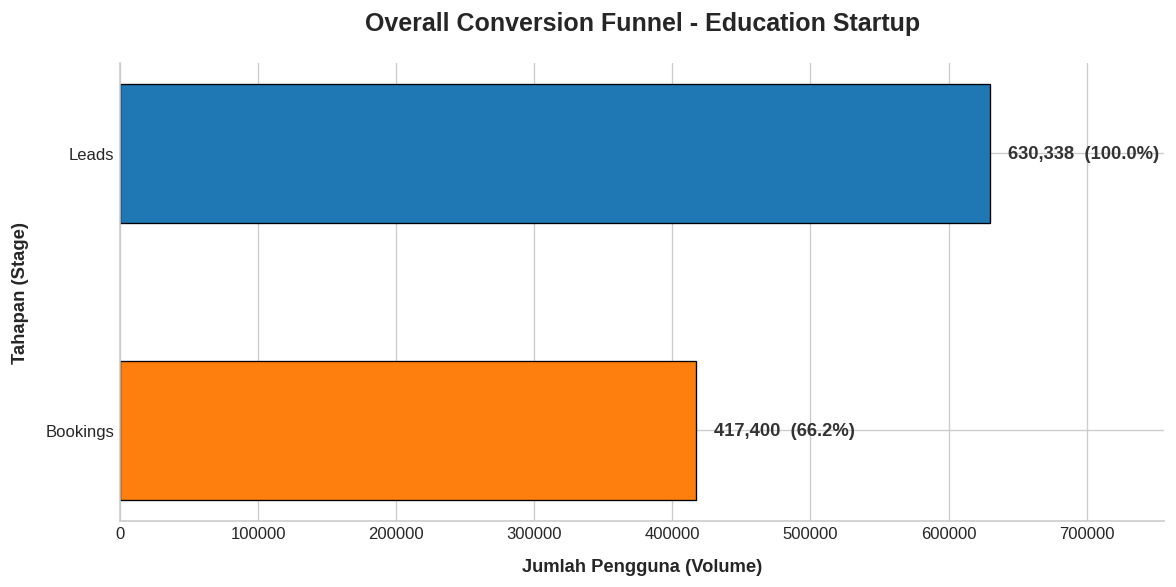

In [40]:
# VISUALISASI FUNNEL CHART
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# Warna profesional
colors = ['#1f77b4', '#ff7f0e']

# Buat Bar Horizontal
bars = ax.barh(funnel_summary['Stage'], funnel_summary['Count'], color=colors, height=0.5, edgecolor='black', linewidth=0.8)

# Atur Judul dan Label Sumbu
ax.set_title('Overall Conversion Funnel - Education Startup', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Jumlah Pengguna (Volume)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Tahapan (Stage)', fontsize=11, fontweight='bold', labelpad=10)

# Membalik Sumbu Y agar Leads berada di atas
ax.invert_yaxis()

# Menghapus garis outline kanan dan atas agar tampilan lebih bersih
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Tambahkan nilai & persentase konversi di ujung bar
for bar, cr, count in zip(bars, funnel_summary['Overall_CR (%)'], funnel_summary['Count']):
    width = bar.get_width()
    ax.text(
        width + (funnel_summary['Count'].max() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f'{int(count):,}  ({cr:.1f}%)',
        va='center',
        ha='left',
        fontweight='bold',
        fontsize=11,
        color='#333333'
    )

# Memperluas batas X agar label teks tidak terpotong
ax.set_xlim(0, funnel_summary['Count'].max() * 1.2)

plt.tight_layout()
plt.show()

## 2.4 Strategic Insights (Funnel)

### Strategic Insights - Funnel Analysis (Education Startup)

1. **Efisiensi Konversi Utama (*Overall Conversion*):**
   * Dari total **630,338 Leads**, sebanyak **417,400 pengguna** berhasil melanjutkan ke tahap **Bookings**, menghasilkan *Overall Conversion Rate* sebesar **66.22%**.

2. **Titik Drop-Off Terbesar:**
   * Terdapat persentase pengguna yang gugur (*Drop-off Rate*) sebesar **33.78%** (212,938 pengguna) dari tahap *Leads* menuju *Bookings*.
   * *Insight:* Hambatan utama bisnis saat ini berada di proses pengubahan minat awal (*Leads*) menjadi reservasi resmi (*Bookings*).

3. **Perbandingan Kinerja antar Segmentasi (*Customer Group Breakdown*):**
   * **Middle School** merupakan segmen paling efisien dengan *Conversion Rate* (*Leads to Bookings*) tertinggi mencapai **71.60%** (234,426 Bookings dari 327,400 Leads).
   * **Kindergarten & Elementary School** berada di posisi kedua dengan konversi **64.96%**.
   * **High School** memiliki konversi terendah, yaitu hanya **59.34%** (*Drop-off* mencapai 40.66%).
   * *Insight:* Target audiens tingkat Sekolah Menengah Pertama (SMP) jauh lebih responsif terhadap penawaran produk pendidikan ini dibandingkan tingkat SMA.

# 3. Strategic Recommendations & Reflection

##3.1 Strategic Recommendations (Rekomendasi Strategis)

Berdasarkan hasil penggabungan **Cohort Analysis** (Fintech) dan **Funnel Analysis** (Education Startup), berikut adalah 3 rekomendasi strategis berbasis data untuk mendorong pertumbuhan bisnis:

1. **Optimasi Konversi Tahap Awal Funnel (*Fix Top-Funnel Drop-off*)**
   * **Temuan Data:** Terdapat *drop-off rate* sebesar **33.78%** dari tahap *Leads* (630,338) ke *Bookings* (417,400).
   * **Aksi Strategis:** Lakukan simplifikasi pada formulir pendaftaran, optimasi kecepatan respon tim sales/admin, serta berikan penawaran gratis (seperti *trial class* atau konsultasi gratis) untuk memicu dorongan pengguna melakukan *booking* pertama.

2. **Alokasi Anggaran Pemasaran pada Segmentasi Kinerja Tinggi (*Focus on High-Performing Group*)**
   * **Temuan Data:** Segmentasi **Middle School** mencatatkan *Conversion Rate* (*Leads to Bookings*) tertinggi sebesar **71.60%**, diikuti oleh *Kindergarten & Elementary* (**64.96%**).
   * **Aksi Strategis:** Tingkatkan alokasi anggaran iklan (*ad spend*) dan kampanye pemasaran pada segmen *Middle School* karena memiliki efisiensi konversi paling optimal, sembari melakukan peninjauan ulang pesan pemasaran pada segmen *High School* (CR hanya **59.34%**).

3. **Inisiatif Re-engagement & Investigasi Anomali Cohort (*Investigate & Retain*)**
   * **Temuan Data:** Cohort **Februari 2024** mengalami penurunan retensi yang sangat tajam di bulan ke-1 (hanya tersisa **26.67%**), sementara Cohort **Juli 2024** mampu mempertahankan hingga **90.0%** pengguna.
   * **Aksi Strategis:**
     * Lakukan audit teknis dan evaluasi kampanye pemasaran pada bulan Februari 2024 untuk mendeteksi potensi isu kualitas akuisisi atau kendala aplikasi.
     * Terapkan strategi *re-engagement* (seperti *push notification*, program loyalitas, atau voucer cashback) bagi cohort yang mengalami *drop* drastis guna meningkatkan retensi jangka panjang.

### 3.2 Reflection Questions (Pertanyaan Refleksi)

#### 1. Mengapa Funnel Analysis saja tidak cukup untuk memahami pertumbuhan bisnis?
> **Jawaban:**
> *Funnel Analysis* hanya mengukur konversi pengguna pada satu titik transaksi/periode waktu (*acquisition & activation*). Analisis funnel tidak dapat memperlihatkan apakah pengguna tersebut puas, tetap menggunakan produk, dan kembali melakukan transaksi di masa depan (*retention*). Tanpa analisis retensi, bisnis bisa tertipu oleh tingginya angka akuisisi awal padahal pengguna langsung pergi setelahnya.

#### 2. Apa insight tambahan yang diberikan Cohort Analysis dibanding Funnel Analysis?
> **Jawaban:**
> *Cohort Analysis* memberikan gambaran mengenai **kesehatan dan keberlanjutan bisnis jangka panjang** (*customer lifetime value & churn rate*) berdasarkan kelompok waktu bergabungnya pengguna. Dengan cohort analysis, kita dapat:
> * Membandingkan kualitas pengguna antar periode kampanye pemasaran yang berbeda.
> * Melacak meluruhnya kesetiaan pengguna seiring berjalannya waktu (*life-cycle analysis*).
> * Mengetahui dampak nyata dari pembaruan fitur atau perubahan strategi produk terhadap retensi pengguna lama.

#### 3. Jika conversion tinggi tetapi retention rendah, apa implikasinya bagi bisnis?
> **Jawaban:**
> Kondisi ini mengindikasikan bisnis mengalami fenomena **"Ember Bocor" (*Leaky Bucket Syndrome*)**:
> * **Pembengkakan CAC:** Biaya akuisisi pelanggan (*Customer Acquisition Cost*) menjadi sangat tinggi dan terbuang sia-sia karena pengguna tidak bertransformasi menjadi pengguna setia.
> * **Nilai LTV Rendah:** Nilai seumur hidup pelanggan (*Customer Lifetime Value*) tidak tercapai secara optimal, sehingga bisnis sulit mencapai titik profitabilitas yang berkelanjutan (*sustainable growth*).
> * **Isu Pada Produk/Layanan:** Menandakan bahwa tim pemasaran (*marketing*) berhasil menarik perhatian pelanggan, tetapi produk (*product experience*) atau layanan purna jual gagal memenuhi ekspektasi pengguna.